https://m.blog.naver.com/luexr/223462833231    => 알고리즘의 이해


# 🧠 K-Means Clustering 예제 (Scikit-learn)

## 📌 개요
- K-Means는 대표적인 비지도 학습 (Unsupervised Learning)
- 데이터를 K개의 그룹으로 자동 분류

---

## 🔥 핵심 아이디어

```text id="kmeans_core"
1. 중심점(k)을 랜덤으로 선택
2. 각 데이터 → 가장 가까운 중심에 할당
3. 중심점 재계산
4. 반복 (수렴할 때까지)

[0 2 0 1 1 1 2 0 1 1 2 2 2 0 2 1 0 0 1 2 1 0 2 0 1 1 0 1 2 2 1 0 0 2 2 1 2
 1 0 2 1 2 0 2 2 1 2 1 1 2 1 2 1 1 2 0 0 1 1 0 2 2 0 1 2 1 0 2 0 2 1 1 1 1
 2 0 2 1 0 0 1 0 2 0 0 0 2 1 0 0 1 2 1 0 2 2 0 2 1 0 2 1 0 2 0 0 1 0 2 2 0
 1 0 0 1 1 0 0 2 2 2 1 2 2 2 1 2 2 2 1 1 1 0 1 1 2 1 0 1 1 2 0 2 0 1 1 0 1
 1 2 0 1 0 2 1 1 2 2 0 2 0 0 2 0 1 0 0 0 0 1 2 0 1 2 2 2 0 2 0 0 2 1 0 0 0
 0 2 1 0 1 0 0 2 2 1 0 2 1 0 1 2 1 0 1 2 1 0 1 0 2 0 0 1 2 2 2 2 0 1 2 0 2
 2 2 0 1 1 0 0 1 0 2 2 0 2 1 1 1 0 0 2 1 1 1 1 2 1 1 0 2 2 0 2 2 1 0 2 1 0
 0 1 0 1 1 0 1 0 2 2 2 2 0 0 0 0 0 1 1 2 0 0 2 2 2 1 2 1 1 2 2 1 1 1 2 0 0
 1 2 0 1]
[[ 0.95625704  4.37226546]
 [-1.60811992  2.85881658]
 [ 1.95159369  0.83467497]]
212.3555034892292
예측 결과 [2]


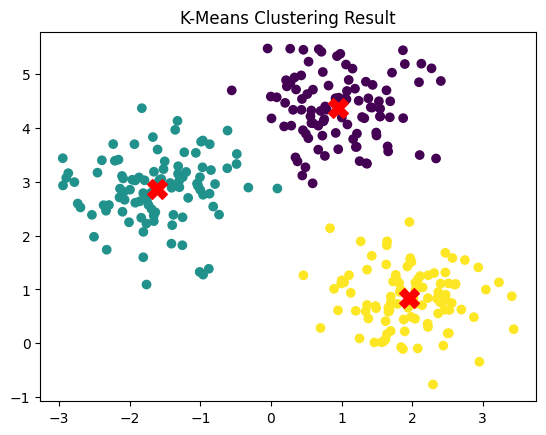

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1️⃣ 데이터 생성 (가짜 데이터)
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=0
)

# 2️⃣ K-Means 모델 생성
kmeans = KMeans(
    n_clusters=3,      # 그룹 개수
    random_state=42
)

# 3️⃣ 학습
kmeans.fit(X)

# 4️⃣ 클러스터 예측
labels = kmeans.labels_
print(labels) #각 데이터가 속한 그룹 번호

# 5️⃣ 중심점
centers = kmeans.cluster_centers_
print(centers)

# 유클리드 거리 제곱의 총합
print(kmeans.inertia_)

pred = kmeans.predict([[2,2]])

print("예측 결과",pred)

# 6️⃣ 시각화
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200)
plt.title("K-Means Clustering Result")
plt.show()


# 🔥 실행 결과 해석
# ✔ 1️⃣ 클러스터 결과
# 데이터가 3개의 그룹으로 나뉨

# 👉 의미:

# 비슷한 데이터끼리 자동 그룹화됨
# ✔ 2️⃣ 중심점 (Centroid)
# 빨간 X = 각 클러스터 중심

# 👉 의미:

# 각 그룹의 대표값
# ✔ 3️⃣ labels_
# [0, 1, 2, 0, 1, ...]

# 👉 의미:

# 각 데이터가 속한 그룹 번호
# 🧠 직관 설명
# 데이터를 3개의 "영역"으로 자동 나눔
# 🔥 과정 흐름
# 랜덤 중심 선택
#       ↓
# 각 점 → 가장 가까운 중심으로 이동
#       ↓
# 중심점 재계산
#       ↓
# 반복
#       ↓
# 수렴
# 💥 중요한 개념
# ✔ Inertia (응집도)
# kmeans.inertia_

# 👉 의미:

# 클러스터 내부 거리 합 (작을수록 좋음)
# 🎯 K 선택 방법 (중요 ⭐)

# 👉 Elbow Method:

# K 증가 → inertia 감소
# 어느 순간 감소폭 줄어듦 → 그 지점 선택
# 📊 장점 / 단점
# ✔ 장점
# 빠름
# 구현 간단
# 대용량 데이터 가능
# ❌ 단점
# K를 직접 정해야 함
# 초기값에 따라 결과 달라짐
# 이상치에 민감
# 🚀 한 줄 요약

# 👉 "K-Means는 데이터를 K개의 중심 기준으로 자동 그룹화하는 알고리즘"

In [8]:
# 미니 프로젝트 고객 세분화
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    "age":[20,22,25,40,45,50],
    "money":[30,40,50,200,180,220]
})

scaler = StandardScaler()
X = scaler.fit_transform(df)
X = df

model=KMeans(
    n_clusters=2
)

pred = model.fit_predict(X)

df["cluster"]=pred

print(df)

   age  money  cluster
0   20     30        0
1   22     40        0
2   25     50        0
3   40    200        1
4   45    180        1
5   50    220        1


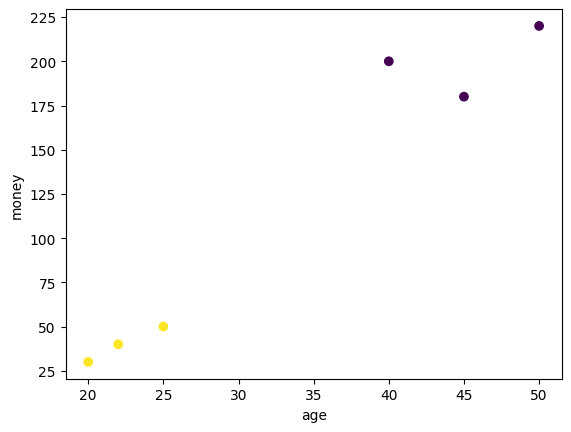

In [7]:
plt.scatter(
    df["age"],
    df["money"],
    c=df["cluster"]
)

plt.xlabel("age")
plt.ylabel("money")

plt.show()